In [27]:
import pandas as pd
import os
import xarray as xr
import matplotlib.pyplot as plt

In [28]:
os.chdir("/home/agritech/Working Directory/Thèses/Dossier_ma_These/Data/map_faidherbia")

In [60]:
os.listdir()

['modified_map2015PFT3.nc',
 'map_TreeCrop_2015.nc',
 'redlist_species_data_63e55ebc-32d5-4975-9069-e0969caec144.zip',
 'PFTmap_2015.nc',
 'T19375471A146219700.jpg',
 '10.2305_IUCN.UK.2019-2.RLTS.T19375471A146219700.en.pdf',
 'map2015PFT3.nc',
 'FG2-mapTest_19030101_19031231_1M_stomate_history.nc',
 'PFTmapSpinupEG2015.nc']

In [65]:
df = xr.open_dataset("map2015PFT3.nc", decode_times=False)
df2 = xr.open_dataset("PFTmap_2015.nc", decode_times=False)
df3 = xr.open_dataset('PFTmapSpinupEG2015.nc', decode_times=False)
df4 = xr.open_dataset('map_TreeCrop_2015.nc', decode_times=False)

In [5]:
#Coordinate SN-Niakhar
LON_WEST=-17
LAT_NORTH=15
LAT_SOUTH=14
LON_EAST=-16

In [95]:
df4["maxvegetfrac"].isel(lat=slice(LAT_NORTH_idx, LAT_SOUTH_idx), lon=slice(LON_WEST_idx, LON_EAST_idx), veget=2).to_dataframe().reset_index()

,time_counter,lat,lon,veget,maxvegetfrac
0,2015.0,15.125,-17.125,3,0.075066
1,2015.0,15.125,-16.875,3,0.109514
2,2015.0,15.125,-16.625,3,0.118445
3,2015.0,15.125,-16.375,3,0.031629
4,2015.0,14.875,-17.125,3,0.031520
5,2015.0,14.875,-16.875,3,0.058400
6,2015.0,14.875,-16.625,3,0.058400
7,2015.0,14.875,-16.375,3,0.058400
8,2015.0,14.625,-17.125,3,0.114045
9,2015.0,14.625,-16.875,3,0.058400


In [90]:
df3["maxvegetfrac"].sel(lat=slice(LAT_NORTH, LAT_SOUTH), lon=slice(LON_WEST, LON_EAST), veget=3).to_dataframe().reset_index()

,time_counter,lat,lon,veget,maxvegetfrac
0,2015.0,14.875,-16.875,3,0.0
1,2015.0,14.875,-16.625,3,0.0
2,2015.0,14.875,-16.375,3,0.0
3,2015.0,14.875,-16.125,3,0.0
4,2015.0,14.625,-16.875,3,0.0
5,2015.0,14.625,-16.625,3,0.0
6,2015.0,14.625,-16.375,3,0.0
7,2015.0,14.625,-16.125,3,0.0
8,2015.0,14.375,-16.875,3,0.0
9,2015.0,14.375,-16.625,3,0.0


In [10]:
df["maxvegetfrac"].sel(lat=slice(LAT_NORTH, LAT_SOUTH), lon=slice(LON_WEST, LON_EAST), veget=3).to_dataframe().reset_index()

,time_counter,lat,lon,veget,maxvegetfrac
0,2015.0,14.875,-16.875,3,1.0
1,2015.0,14.875,-16.625,3,1.0
2,2015.0,14.875,-16.375,3,1.0
3,2015.0,14.875,-16.125,3,1.0
4,2015.0,14.625,-16.875,3,1.0
5,2015.0,14.625,-16.625,3,1.0
6,2015.0,14.625,-16.375,3,1.0
7,2015.0,14.625,-16.125,3,1.0
8,2015.0,14.375,-16.875,3,1.0
9,2015.0,14.375,-16.625,3,1.0


In [44]:
df2["maxvegetfrac"].sel(lat=slice(LAT_NORTH, LAT_SOUTH), lon=slice(LON_WEST, LON_EAST), veget=3).to_dataframe().reset_index()

,time_counter,lat,lon,veget,maxvegetfrac
0,2015.0,14.875,-16.875,3,0.071623
1,2015.0,14.875,-16.625,3,0.027120
2,2015.0,14.875,-16.375,3,0.007242
3,2015.0,14.875,-16.125,3,0.012722
4,2015.0,14.625,-16.875,3,0.035709
5,2015.0,14.625,-16.625,3,0.033967
6,2015.0,14.625,-16.375,3,0.009032
7,2015.0,14.625,-16.125,3,0.025105
8,2015.0,14.375,-16.875,3,0.023288
9,2015.0,14.375,-16.625,3,0.036902


In [78]:

def geo_idx(dd, dd_array):
  import numpy as np
  """
  search for nearest decimal degree in an array of decimal degrees and return the index.
  np.argmin returns the indices of minium value along an axis.
  so subtract dd from all values in dd_array, take absolute value and find index of minimum.
  """
  geo_idx = (np.abs(dd_array - dd)).argmin()
  return geo_idx
# a function to find the index of the point closest (in squared distance) to give lat/lon value.


def getclosest_ij(lats,lons,latpt,lonpt):#Fonctionne
    import numpy as np
    dist_sq = (lats-latpt)**2 + (lons-lonpt)**2  # find squared distance of every point on grid
    minindex_flattened = dist_sq.argmin() # 1D index of minimum dist_sq element
    # Get 2D index for latvals and lonvals arrays from 1D index
    return np.unravel_index(minindex_flattened, latvals.shape)

In [12]:
lat, lon = df.variables['lat'], df.variables['lon']
latvals = lat[:]; lonvals = lon[:] # extract lat/lon values (in degrees) to numpy arrays

In [13]:
LON_WEST_idx = geo_idx(LON_WEST, lonvals)
LAT_NORTH_idx = geo_idx(LAT_NORTH, latvals)
LAT_SOUTH_idx = geo_idx(LAT_SOUTH, latvals)
LON_EAST_idx = geo_idx(LON_EAST, lonvals)
LON_WEST_idx, LAT_NORTH_idx, LAT_SOUTH_idx, LON_EAST_idx


/tmp/ipykernel_194825/2378731899.py:8: DeprecationWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  geo_idx = (np.abs(dd_array - dd)).argmin()
/tmp/ipykernel_194825/2378731899.py:8: DeprecationWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  geo_idx = (np.abs(dd_array - dd)).argmin()
/tmp/ipykernel_194825/2378731899.py:8: DeprecationWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  geo_idx 

(<xarray.Variable ()>
 array(651),
 <xarray.Variable ()>
 array(299),
 <xarray.Variable ()>
 array(303),
 <xarray.Variable ()>
 array(655))

In [ ]:
iy_min, ix_min = getclosest_ij(latvals, lonvals, LAT_SOUTH, LON_WEST)
iy_min, ix_min

In [102]:
import netCDF4
import os
file_path = 'map_TreeCrop_2015.nc'
if os.path.exists(file_path):
    nc = netCDF4.Dataset(file_path, "r")
else:
    print(f"The file '{file_path}' does not exist.")


In [103]:
nc

<class 'netCDF4._netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    date: 29/11/2017 18:19
    web: https://orchidas.lsce.ipsl.fr/dev/LCCCI.php
    contact: V.Bastrikov (vladislav.bastrikov@lsce.ipsl.fr), P.Peylin (philippe.peylin@lsce.ipsl.fr), N.Vuichard (nicolas.vuichard@lsce.ipsl.fr)
    resolution: Regular lat/lon 0.25-degree
    description: ORCHIDEE PFT map based on the ESA CCI Land Cover map v2.0.7b for 2010 aggregated by the user-tool v3.13 with the cross-walking table v2.4, followed by historical reconstrution using G. Hurtt data LU2v2h with merging rules v2.0
    history: Fri Apr 27 17:45:04 2018: ncks -4 /ccc/work/cont003/igcmg/igcmg/IGCM/SRF/PFTMAPS/CMIP6/ESA-LUH2v2/historical/15PFT.v1/PFTmap_2015.nc /ccc/work/cont003/igcmg/igcmg/IGCM/SRF/PFTMAPS/CMIP6/ESA-LUH2v2/historical/15PFT.v2/PFTmap_2015.nc
    NCO: 4.4.8
    dimensions(sizes): time_counter(1), lat(720), lon(1440), veget(15)
    variables(dimensions): float64 lat(lat), float64 lon(lon), float32

In [104]:
lat, lon = nc.variables['lat'], nc.variables['lon']
latvals = lat[:]; lonvals = lon[:] # extract lat/lon values (in degrees) to numpy arrays

In [105]:
LON_WEST_idx = geo_idx(LON_WEST, lonvals)
LAT_NORTH_idx = geo_idx(LAT_NORTH, latvals)
LAT_SOUTH_idx = geo_idx(LAT_SOUTH, latvals)
LON_EAST_idx = geo_idx(LON_EAST, lonvals)
LON_WEST_idx, LAT_NORTH_idx, LAT_SOUTH_idx, LON_EAST_idx

(651, 299, 303, 655)

In [106]:
nc.variables["maxvegetfrac"][0, 2, LAT_NORTH_idx:LAT_SOUTH_idx, LON_WEST_idx:LON_EAST_idx] 

masked_array(
  data=[[0.0750659 , 0.10951397, 0.11844505, 0.03162868],
        [0.03151969, 0.0584    , 0.0584    , 0.0584    ],
        [0.11404487, 0.0584    , 0.0584    , 0.0584    ],
        [0.07357927, 0.0584    , 0.0584    , 0.0584    ]],
  mask=False,
  fill_value=1e+20,
  dtype=float32)

In [108]:
prop_tree = 0.0584
prop_crop = 1 - prop_tree

if prop_crop + prop_tree != 1.0:
    print(f"Erreur la somme doit donner 1, ta somme donne plutôt {prop_crop + prop_tree}")
else:
    for ipft in range(0,15):
        if ipft == 2:
            nc.variables["maxvegetfrac"][0, ipft, LAT_NORTH_idx:LAT_SOUTH_idx, LON_WEST_idx:LON_EAST_idx] = prop_tree
        elif ipft == 12:
            nc.variables["maxvegetfrac"][0, ipft, LAT_NORTH_idx:LAT_SOUTH_idx, LON_WEST_idx:LON_EAST_idx] = prop_crop
        else:
            nc.variables["maxvegetfrac"][0, ipft, LAT_NORTH_idx:LAT_SOUTH_idx, LON_WEST_idx:LON_EAST_idx] = 0

RuntimeError: NetCDF: HDF error

In [98]:
nc.variables["maxvegetfrac"][0, 2, LAT_NORTH_idx:LAT_SOUTH_idx, LON_WEST_idx:LON_EAST_idx] 

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]

In [ ]:
nc.close()

In [80]:
lat, lon = nc.variables['lat'], nc.variables['lon']
latvals = lat[:]; lonvals = lon[:] # extract lat/lon values (in degrees) to numpy arrays

In [30]:
import netCDF4 as nc
import xarray as xr
import numpy as np

# Define the file path
file_path = "map2015PFT3.nc"

# Open the NetCDF file
dataset = df

# Define the coordinates to search for
LON_WEST = -17
LAT_NORTH = 15
LAT_SOUTH = 14
LON_EAST = -16

# Find the indices for the specified coordinates
lon_indices = np.where((dataset.lon >= LON_WEST) & (dataset.lon <= LON_EAST))[0]
lat_indices = np.where((dataset.lat <= LAT_NORTH) & (dataset.lat >= LAT_SOUTH))[0]

# Define the values to replace for veget=3 and veget=13
replace_values = {
    3: 0.3,
    13: 0.7,
}

# Iterate through veget values and update "maxvegetfrac" variable
for veget, replace_value in replace_values.items():
    # Replace values for the specified coordinates
    dataset['maxvegetfrac'][0, veget - 1, lat_indices, lon_indices] = replace_value

# Replace all other veget values with 0
other_veget_indices = [v - 1 for v in dataset.veget.values if v not in replace_values]
dataset['maxvegetfrac'][0, other_veget_indices, lat_indices, lon_indices] = 0.0

# Save the modified dataset back to a new NetCDF file
output_file = "modified_map2015PFT3.nc"
dataset.to_netcdf(output_file)

# Close the dataset
dataset.close()

print("Modification complete. Saved as", output_file)


NameError: name 'output_file' is not defined

In [31]:
other_veget_indices

[0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14]

In [96]:
lon_indices

array([652, 653, 654, 655])

In [37]:
dataset = xr.open_dataset("modified_map2015PFT3.nc", decode_times=False)

In [40]:
tx = xr.open_dataset("FG2-mapTest_19030101_19031231_1M_stomate_history.nc")

In [64]:

tx.VEGET_MAX.isel(time_counter=1).to_dataframe()

,,,time_centered,time_counter,VEGET_MAX
veget,lat,lon,,,
1.0,15.0,-17.0,1903-01-02 12:00:00,1903-01-02 12:00:00,0.080645
2.0,15.0,-17.0,1903-01-02 12:00:00,1903-01-02 12:00:00,0.047780
3.0,15.0,-17.0,1903-01-02 12:00:00,1903-01-02 12:00:00,0.082394
4.0,15.0,-17.0,1903-01-02 12:00:00,1903-01-02 12:00:00,0.030705
5.0,15.0,-17.0,1903-01-02 12:00:00,1903-01-02 12:00:00,0.000000
6.0,15.0,-17.0,1903-01-02 12:00:00,1903-01-02 12:00:00,0.000000
7.0,15.0,-17.0,1903-01-02 12:00:00,1903-01-02 12:00:00,0.000000
8.0,15.0,-17.0,1903-01-02 12:00:00,1903-01-02 12:00:00,0.000000
9.0,15.0,-17.0,1903-01-02 12:00:00,1903-01-02 12:00:00,0.000000


In [39]:
dataset["maxvegetfrac"].sel(lat=slice(LAT_NORTH, LAT_SOUTH), lon=slice(LON_WEST, LON_EAST), veget=13).to_dataframe().reset_index()

,time_counter,lat,lon,veget,maxvegetfrac
0,2015.0,14.875,-16.875,13,0.7
1,2015.0,14.875,-16.625,13,0.7
2,2015.0,14.875,-16.375,13,0.7
3,2015.0,14.875,-16.125,13,0.7
4,2015.0,14.625,-16.875,13,0.7
5,2015.0,14.625,-16.625,13,0.7
6,2015.0,14.625,-16.375,13,0.7
7,2015.0,14.625,-16.125,13,0.7
8,2015.0,14.375,-16.875,13,0.7
9,2015.0,14.375,-16.625,13,0.7


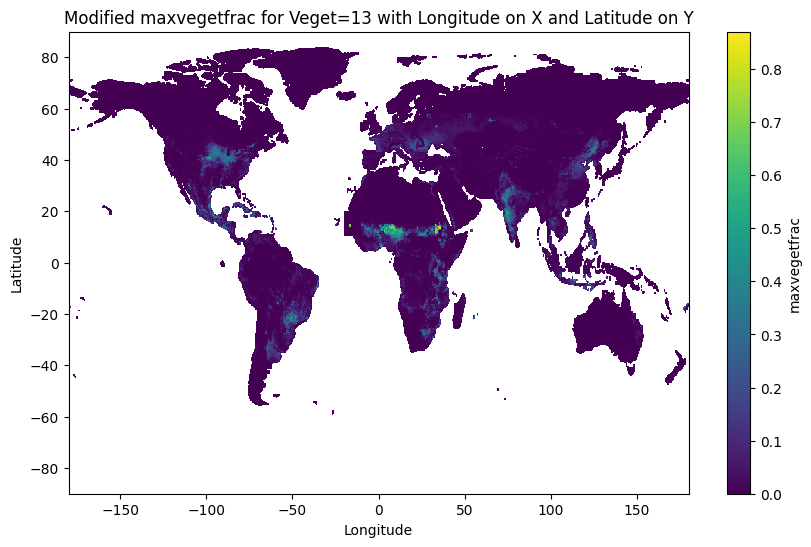

In [25]:
import netCDF4 as nc
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# Define the file path (make sure it points to the modified NetCDF file)
file_path = "modified_map2015PFT3.nc"

# Open the modified NetCDF file
dataset = xr.open_dataset(file_path, decode_times=False)

# Extract the modified maxvegetfrac variable
maxvegetfrac = dataset['maxvegetfrac'][0].values  # Assuming the first time step

# Get latitude and longitude values
latitudes = dataset.lat.values
longitudes = dataset.lon.values

# Choose a specific veget value to plot (e.g., veget=3)
veget_value = 13
veget_index = veget_value - 1  # Convert to zero-based index

# Extract the values for the selected veget value
veget_data = maxvegetfrac[veget_index, :, :]

# Create a plot
plt.figure(figsize=(10, 6))
plt.pcolormesh(longitudes, latitudes, veget_data, cmap='viridis')
plt.colorbar(label='maxvegetfrac')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f'Modified maxvegetfrac for Veget={veget_value} with Longitude on X and Latitude on Y')

# Show the plot
plt.show()








In [34]:
gw = xr.open_mfdataset('/home/agritech/Working Directory/Thèses/Dossier_ma_These/Data/SWC_nc_data/VWC_obs_GAPFILLED_Nkr_solay_full_120_*.nc')

In [35]:
gw.data_vars

Data variables:
    moistc_1  (time_counter, z, lat, lon) float32 dask.array<chunksize=(366, 120, 1, 1), meta=np.ndarray>
    moistc_2  (time_counter, z, lat, lon) float32 dask.array<chunksize=(366, 120, 1, 1), meta=np.ndarray>
    moistc_3  (time_counter, z, lat, lon) float32 dask.array<chunksize=(366, 120, 1, 1), meta=np.ndarray>

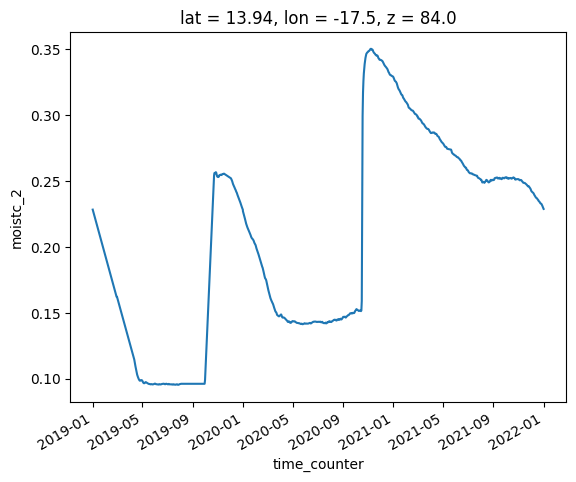

In [36]:
gw.moistc_2.sel(z=84).plot()